# Tugas 1
Memahami kosep preprae dan eksplorasi data untuk membuat visualisasi yang mengimplementasikan konsep Editorial Focus

# Editorial Focus

## Datasets

This dataset comprises a set of users and their visits to various points-of-interests (POIs) in eight cities. The user-POI visits are determined based on geo-tagged YFCC100M Flickr photos that are:


1.   Mapped to specific POIs location and POI categories; and
2.   Grouped into individual travel sequences (consecutive user-POI visits that differ by <8hrs). Other associated datasets are the "List of POIs" dataset ("POI-{cityName}.csv" files from "poiList-ijcai15.zip") and "POI Cost-Profit Table" dataset ("costProfCat-{cityName}POI-all.csv" files from "costProf-ijcai15.zip")

Link: https://drive.google.com/file/d/1ryshHuWKnBijXJgvaSCv-KsSUhVGhpIJ/view

## Identifikasi cerita

Tujuan utama dari fokus editorial adalah untuk menentukan cerita yang ingin Anda sampaikan melalui data

## Perjelas dengan Pertanyaan

Saat mengembangkan fokus editorial, pikirkan tentang pertanyaan-pertanyaan apa yang ingin Anda jawab untuk pembaca melalui visualisasi data Anda. Ini membantu menentukan arah analisis yang akan dilakukan

# Task

Berdasarkan uraian di atas maka lakukan
1. Pahami dan deskripsikan datasets yang disediakan
2. Identifikasi cerita yang akan anda sampaikan berdasarkan dataset yang disediakan
3. Berdasarkan pada point 2, deskripisikan pertanyaan yang mungkin muncul dari pembaca dan berdasarkan pertanyaan tersebut, data apa yang akan ditampilkan (data abstraction)? mengapa pengguna ingin melihatnya melihatnya
4. Lakukan analisis visual pada dataset type tabel dengan menggunakan 0, 1, 2, ... key





# VDI 2.0

# Pre-processing Data

## Data gowalla_cheackins

In [3]:
import pandas as pd

In [14]:
#import data excel
data = pd.read_excel('/content/gowalla_checkins.xlsx')
data3 = pd.DataFrame(data)
data3.head()

,userid,placeid,datetime
0,1338,482954,2011-06-23T02:24:22Z
1,1338,580963,2011-06-22T14:23:03Z
2,1338,365256,2011-06-09T23:29:30Z
3,1338,89504,2011-05-22T15:54:30Z
4,1338,1267135,2011-05-21T16:51:13Z


In [15]:
#melihat ukuran data awal
data3.shape

(1048575, 3)

In [16]:
data3.isnull().sum()

#ternyata data_checkins tidak terdapat missing value

,0
userid,0
placeid,0
datetime,0


In [17]:
# Ubah kolom datetime menjadi tipe datetime
data3['datetime'] = pd.to_datetime(data3['datetime'])

# Ekstrak jam dari kolom datetime
data3['hour'] = data3['datetime'].dt.hour

In [18]:
# Hitung frekuensi aktivitas tiap jam
hourly_activity = data3['hour'].value_counts().sort_index()

# Lihat hasil
print(hourly_activity)

hour
0     53424
1     45737
2     37521
3     30867
4     27907
5     24276
6     23239
7     21652
8     19481
9     19745
10    22493
11    27835
12    33985
13    41460
14    47168
15    54040
16    64989
17    74254
18    73292
19    67674
20    63585
21    58243
22    57690
23    58018
Name: count, dtype: int64


In [22]:
#mencetak data dalam bentuk Data Frame
data_hour = pd.DataFrame(hourly_activity)
data_hour

,count
hour,
0,53424
1,45737
2,37521
3,30867
4,27907
5,24276
6,23239
7,21652
8,19481


In [23]:
#Menyimpan data_checkins ke dalam file excel dan siap divisualisasikan
data_hour = data_hour.to_excel('data_hour.xlsx', index=False)

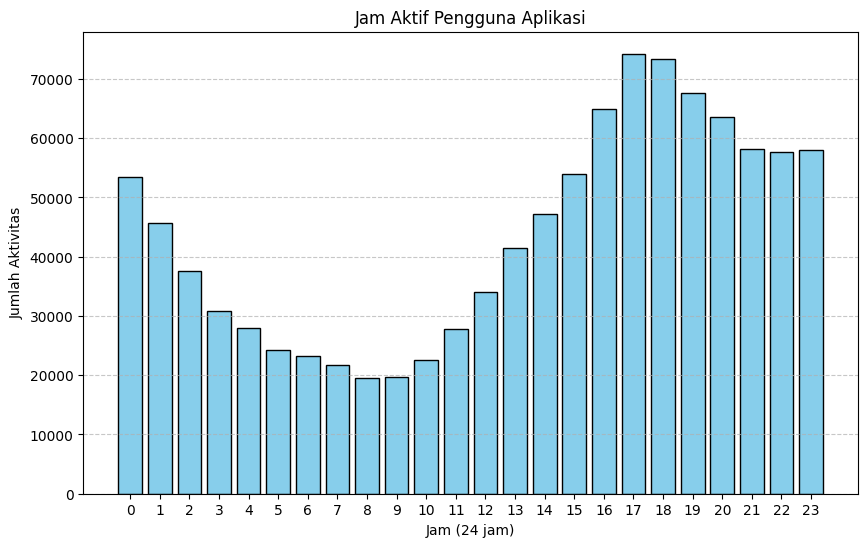

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(hourly_activity.index, hourly_activity.values, color='skyblue', edgecolor='black')
plt.xticks(range(0, 24))  # Menampilkan semua jam dari 0 hingga 23
plt.xlabel('Jam (24 jam)')
plt.ylabel('Jumlah Aktivitas')
plt.title('Jam Aktif Pengguna Aplikasi')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Data gowalla_spots_subsets1

In [27]:
data_subset1 = pd.read_csv('/content/gowalla_spots_subset1.csv')
data_subset1 = pd.DataFrame(data_subset1)
data_subset1.head()

,id,created_at,lng,lat,photos_count,checkins_count,users_count,radius_meters,highlights_count,items_count,max_items_count,spot_categories
0,8904,2008-12-06T16:28:53Z,-94.607499,39.052318,0.0,114.0,21.0,35.0,0.0,10.0,10.0,"[{'url': '/categories/89', 'name': 'Craftsman'}]"
1,8932,2008-12-13T02:16:51Z,-97.254356,32.927662,2.0,67.0,48.0,75.0,0.0,6.0,10.0,"[{'url': '/categories/17', 'name': 'BBQ'}]"
2,8936,2008-12-14T22:08:39Z,-94.591995,39.053318,0.0,75.0,46.0,75.0,0.0,10.0,10.0,"[{'url': '/categories/103', 'name': 'Theatre'}]"
3,8938,2008-12-15T00:22:49Z,-94.590311,39.052824,38.0,438.0,94.0,50.0,10.0,10.0,10.0,"[{'url': '/categories/1', 'name': 'Coffee Shop'}]"
4,8947,2008-12-16T23:14:05Z,-122.029631,37.331880,91.0,3100.0,1186.0,200.0,20.0,10.0,10.0,"[{'url': '/categories/121', 'name': 'Corporate..."


In [28]:
#Cek missing value
data_subset1.isnull().sum()

,0
id,0
created_at,0
lng,1
lat,1
photos_count,1
checkins_count,1
users_count,1
radius_meters,1
highlights_count,1
items_count,1


In [29]:
#hapus sampel missing value
data_subset1 = data_subset1.dropna()

#Cek missing value
#ternyata data sudah bersih
data_subset1.isnull().sum()

,0
id,0
created_at,0
lng,0
lat,0
photos_count,0
checkins_count,0
users_count,0
radius_meters,0
highlights_count,0
items_count,0


In [32]:
# Ubah kolom datetime menjadi tipe datetime
data_subset1['created_at'] = pd.to_datetime(data_subset1['created_at'])

# Ekstrak jam dari kolom datetime
data_subset1['hour'] = data_subset1['created_at'].dt.hour

In [33]:
import pandas as pd

# Ambil hanya kolom yang diperlukan
data_analysis = data_subset1[['created_at', 'checkins_count']].copy()

# Ubah kolom datetime menjadi tipe datetime jika belum
data_analysis['created_at'] = pd.to_datetime(data_analysis['created_at'])

# Ekstrak jam dari datetime
data_analysis['hour'] = data_analysis['created_at'].dt.hour

# Kelompokkan berdasarkan jam dan jumlahkan checkins_count
hourly_checkins = data_analysis.groupby('hour')['checkins_count'].sum().reset_index()

# Ganti nama kolom agar lebih informatif
hourly_checkins.columns = ['Hour', 'Total Checkins']

# Tampilkan hasil analisis
print(hourly_checkins)

    Hour  Total Checkins
0      0        257920.0
1      1        204110.0
2      2        158792.0
3      3        161289.0
4      4         88154.0
5      5         59198.0
6      6         40173.0
7      7         35034.0
8      8         22988.0
9      9         38644.0
10    10         54334.0
11    11         68054.0
12    12         73452.0
13    13        105172.0
14    14        164836.0
15    15        192068.0
16    16        283785.0
17    17        376532.0
18    18        275403.0
19    19        321868.0
20    20        259836.0
21    21        228710.0
22    22        324802.0
23    23        311826.0


In [35]:
#Menyimpan data jam checkins ke dalam excel untuk visualisasi
hourly_checkins.to_excel('hourly_checkins.xlsx', index=False)

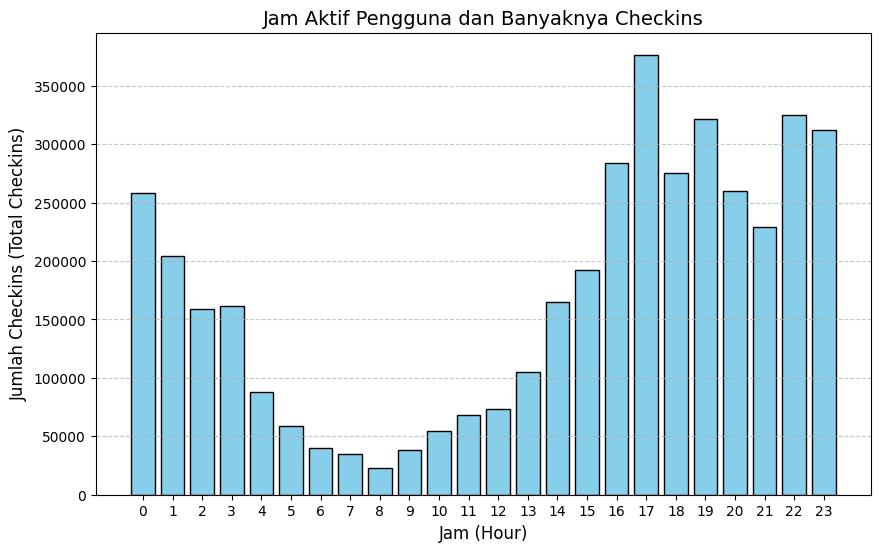

In [34]:
# Plot hasil analisis (opsional)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(hourly_checkins['Hour'], hourly_checkins['Total Checkins'], color='skyblue', edgecolor='black')
plt.title('Jam Aktif Pengguna dan Banyaknya Checkins', fontsize=14)
plt.xlabel('Jam (Hour)', fontsize=12)
plt.ylabel('Jumlah Checkins (Total Checkins)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Data gowalla_spots_subsets2

In [56]:
data_spot = pd.read_csv('/content/gowalla_spots_subset2.csv', encoding='ISO-8859-1')
data_spot = pd.DataFrame(data_spot)
data_spot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120997 entries, 0 to 120996
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          120997 non-null  int64  
 1   lat         120997 non-null  float64
 2   lng         120997 non-null  float64
 3   name        120997 non-null  object 
 4   city_state  107033 non-null  object 
 5   Unnamed: 5  5 non-null       object 
 6   Unnamed: 6  1 non-null       object 
dtypes: float64(2), int64(1), object(4)
memory usage: 6.5+ MB


In [57]:
data_spot.isnull().sum()

#Ternyata dalam kolom 'city_state' terdapat cukup banyak missing value > 13.000 sampel
#kami memustuskan untuk tidak menghapus data tersebut, dan melakukan beberapa treatment khusus untuk mennaganinya

,0
id,0
lat,0
lng,0
name,0
city_state,13964
Unnamed: 5,120992
Unnamed: 6,120996


In [58]:
#cek dimensi data awal
data_spot.shape

(120997, 7)

In [62]:
# Cek beberapa baris pertama
print(data_spot.head())

# Periksa kolom 'city_state' untuk melihat apakah ada nilai yang tidak terduga
print(data_spot['city_state'].unique())

      id        lat         lng                   name    city_state  \
0   9813  36.631508 -121.912022          Pacific Ocean   Seaside, CA   
1  11981  40.690173  -74.045491       Refreshment Park  New York, NY   
2  12455  36.642022  -93.284912  Mickey Gilley Theatre   Branson, MO   
3  12455  36.642022  -93.284912  Mickey Gilley Theatre   Branson, MO   
4  13810  42.548879  -82.902768                 Jaword   Clinton, MI   

  Unnamed: 5 Unnamed: 6                        full_location  
0        NaN        NaN          Seaside, CA - Pacific Ocean  
1        NaN        NaN      New York, NY - Refreshment Park  
2        NaN        NaN  Branson, MO - Mickey Gilley Theatre  
3        NaN        NaN  Branson, MO - Mickey Gilley Theatre  
4        NaN        NaN                 Clinton, MI - Jaword  
['Seaside, CA' 'New York, NY' 'Branson, MO' ... 'Manchester, MD'
 'Mount Wolf, PA' 'Devon, PA']


In [77]:
# Cek apakah ada nilai kosong di kolom 'city_state'
print("Jumlah missing value:", data_spot['city_state'].isnull().sum())
#ternya setelah dicek lebih lanjut, kolom 'city_state' tidak ada missing value

# Cek beberapa nilai unik di kolom 'city_state'
print("\nKategori unik dalam:", data_spot['city_state'].unique())

Jumlah missing value: 0

Kategori unik dalam: ['seaside ca' 'new york ny' 'branson mo' ... 'manchester md'
 'mount wolf pa' 'devon pa']


In [64]:
# Menghapus spasi ekstra di awal dan akhir string di kolom 'city_state'
data_spot['city_state'] = data_spot['city_state'].str.strip()

# Cek lagi nilai unik setelah di-trim
print(data_spot['city_state'].unique())

['Seaside, CA' 'New York, NY' 'Branson, MO' ... 'Manchester, MD'
 'Mount Wolf, PA' 'Devon, PA']


In [65]:
# Cek apakah ada variasi dalam penulisan
print(data_spot['city_state'].value_counts())

city_state
Unknown                      13964
Austin, TX                    1506
Stockholm                     1301
Riyadh                        1009
Oslo                           959
                             ...  
Gifford Pinchot, WA              1
Pendleton, SC                    1
Saumarez, New South Wales        1
Upper Lake, CA                   1
Devon, PA                        1
Name: count, Length: 16761, dtype: int64


In [66]:
# Periksa nilai yang hilang secara eksplisit
missing_data = data_spot[data_spot['city_state'].isna()]
print(missing_data)

Empty DataFrame
Columns: [id, lat, lng, name, city_state, Unnamed: 5, Unnamed: 6, full_location]
Index: []


In [68]:
#Normalisasi data supaya menghindari huruf besar dan kecil yang tidak terdeteksi
# Mengubah semua nama lokasi menjadi huruf kecil
data_spot['city_state'] = data_spot['city_state'].str.lower()

# Misalnya, jika ada tanda koma berlebih atau karakter lain yang tidak perlu
data_spot['city_state'] = data_spot['city_state'].str.replace(',', '')  # Menghapus koma

import re

# Misalnya, mengganti spasi yang berlebihan menjadi satu spasi
data_spot['city_state'] = data_spot['city_state'].apply(lambda x: re.sub(r'\s+', ' ', x))

In [70]:
# Mengganti penulisan dengan format yang konsisten
data_spot['city_state'] = data_spot['city_state'].replace({
    'new york, ny': 'New York, NY',
    'los angeles, ca': 'Los Angeles, CA',
    # Tambahkan lebih banyak penggantian sesuai kebutuhan
})

data_spot['city_state'].unique()

array(['seaside ca', 'new york ny', 'branson mo', ..., 'manchester md',
       'mount wolf pa', 'devon pa'], dtype=object)

In [71]:
# Cek kembali variasi penulisan setelah pembersihan
print(data_spot['city_state'].value_counts())

city_state
unknown                     13964
austin tx                    1506
stockholm                    1301
riyadh                       1009
oslo                          959
                            ...  
gifford pinchot wa              1
pendleton sc                    1
saumarez new south wales        1
upper lake ca                   1
devon pa                        1
Name: count, Length: 16761, dtype: int64


In [73]:
import pandas as pd

# Menghapus baris dengan nilai 'Unknown' di kolom 'city_state'
#sehingga akan fokus untuk menghitung lokasi yang terdeteksi saja
data_spot_filtered = data_spot[data_spot['city_state'] != 'unknown']

# Menghitung jumlah kunjungan per lokasi
location_counts = data_spot_filtered['city_state'].value_counts()

# Menampilkan 10 lokasi paling banyak dikunjungi
top_locations = location_counts.head(10)
print("10 Lokasi Paling Banyak Dikunjungi (kecuali 'Unknown'):")
print(top_locations)

10 Lokasi Paling Banyak Dikunjungi (kecuali 'Unknown'):
city_state
austin tx      1506
stockholm      1301
riyadh         1009
oslo            959
jakarta         874
tokyo           769
new york ny     751
moscow          715
taipei city     602
singapore       558
Name: count, dtype: int64


In [75]:
#Menyimpan data 10 lokasi terpopuler ke dalam file excel untuk divisualisasikan
top_locations.to_excel('top_locations.xlsx')